Facemap Model

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import torch 
from sklearn.metrics import r2_score
import sys
from facemap_model import KeypointsNetwork
from preprocessing import preprocess_features, out_list, sessions_list


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [3]:
# Read and Process Kinematic Features 
feats = pd.read_csv('/Volumes/research/eng_research_economo/OE/Data - All Neural and Kinematic Activity/Kinematics Data/YH35_240828_Kinematics_All.csv')

trial_len = 1480 # Points per Trial

X = preprocess_features(feats, trial_len) # Expects a 2D Matrix (time points * trials, features) -- Returns a 3D Matrix (trials, time points, features)

In [5]:
# Load Model 
input_dim = X.shape[2]
Animal = 0 # When Using Model

device = torch.device('cpu')

model = KeypointsNetwork(n_in = 55, n_kp = None, out_list = out_list, sessions_list = sessions_list)
model.load_state_dict(torch.load(f'Model_Trained_on_All_FaceMap.pth', map_location = device)) # Load Trained Parameters

<All keys matched successfully>

In [6]:
# Model Output
with torch.no_grad():
    output = model(X) # Facemap output = 256 Dimensions

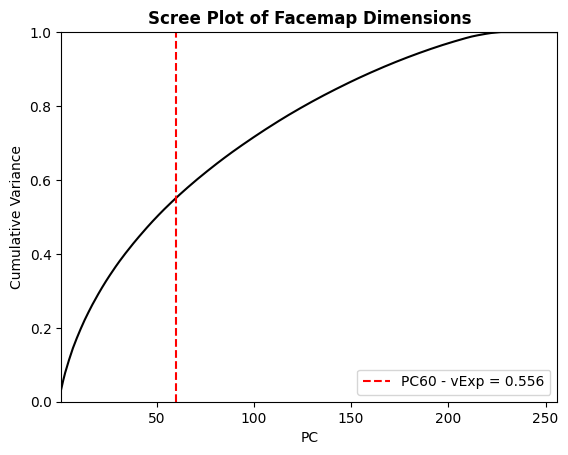

In [8]:
# PCA on Facemap Output 
def PCA(output, PCs, trial_len): 
    Y = output.cpu().numpy()

    # Reshape to (time points * trials, 128 Dims)
    Y = Y.reshape((Y.shape[0] * Y.shape[1], Y.shape[2]))
    
    # Perform SVD
    A = (Y - np.mean(Y, axis=0)).T
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    V = Vt.T

    # Cumulative Variance 
    vExp = [S[i]/np.sum(S) for i in range(len(S))]
    cVar = []

    temp_var = 0.0
    for i in range(len(S)):
        temp_var += vExp[i]
        cVar.append(temp_var)

    # Scree Plot
    plt.plot(range(1, 1 + len(S)),cVar, color = 'k')
    plt.ylim((0,1))
    plt.xlim((1, len(S)))
    plt.xlabel('PC')
    plt.ylabel('Cumulative Variance')
    plt.axvline(x = PCs, color = 'r', linestyle = '--', label = f'PC{PCs} - vExp = {cVar[PCs]:.3f}')
    plt.title('Scree Plot of Facemap Dimensions', fontweight = 'bold')
    plt.legend()

    # Perform Dimensionality Reduction
    S = np.diag(S)
    Y_pc = V[:, :PCs] @ S[:PCs, :PCs]
    Y_pc = Y_pc.reshape((Y_pc.shape[0] // trial_len, trial_len, PCs))


    return Y_pc, vExp[:PCs]


PCs = 60
Predicted_PCs, vExp = PCA(output, PCs, trial_len) # Returns Neural PCs and Plots Scree Plot

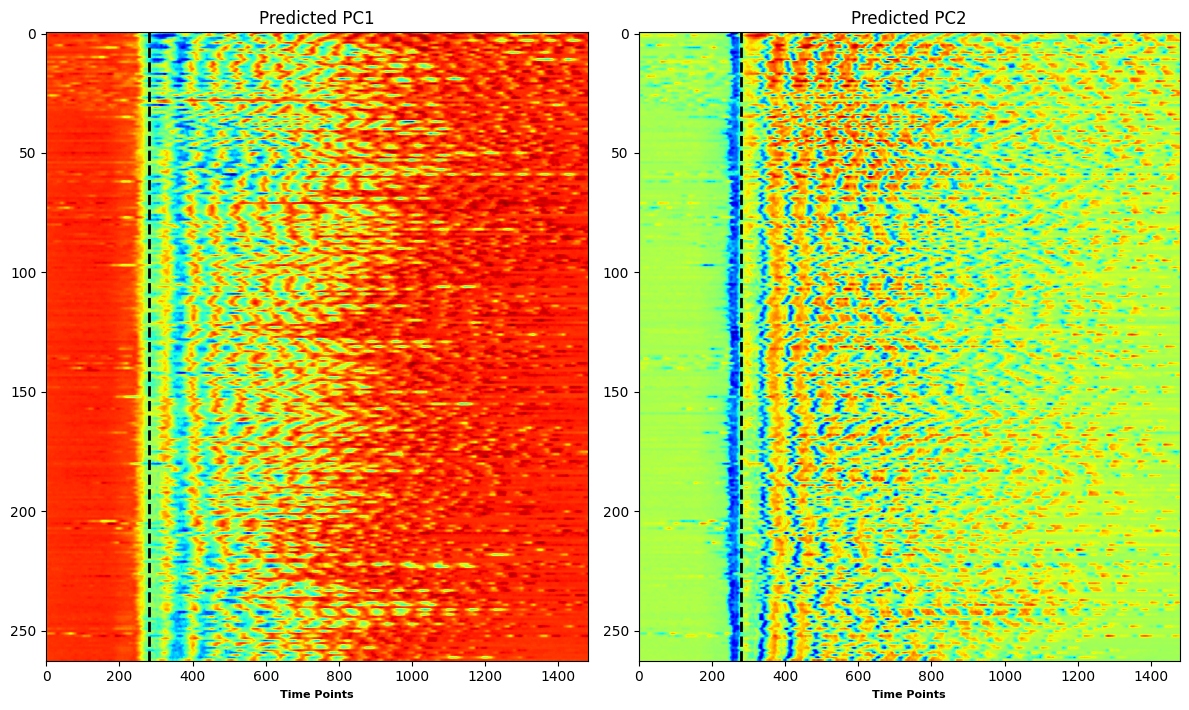

In [14]:
# Plot Heat Maps of PCs

fig, axs = plt.subplots(1, 2, figsize=(12, 8))

axs[0].imshow(Predicted_PCs[:,:,0], aspect='auto', cmap='jet', origin='upper')
axs[0].set_xlabel('Time Points', fontweight='bold', fontsize=8)
axs[0].axvline(x=280, color='k', linestyle='--', linewidth=2)
axs[0].set_title('Predicted PC1')

axs[1].imshow(Predicted_PCs[:,:,1], aspect='auto', cmap='jet', origin='upper')
axs[1].set_xlabel('Time Points', fontweight='bold', fontsize=8)
axs[1].set_title('Predicted PC2')
axs[1].axvline(x=280, color='k', linestyle='--', linewidth=2)

plt.tight_layout(rect=[0, 0, 1, 0.90])

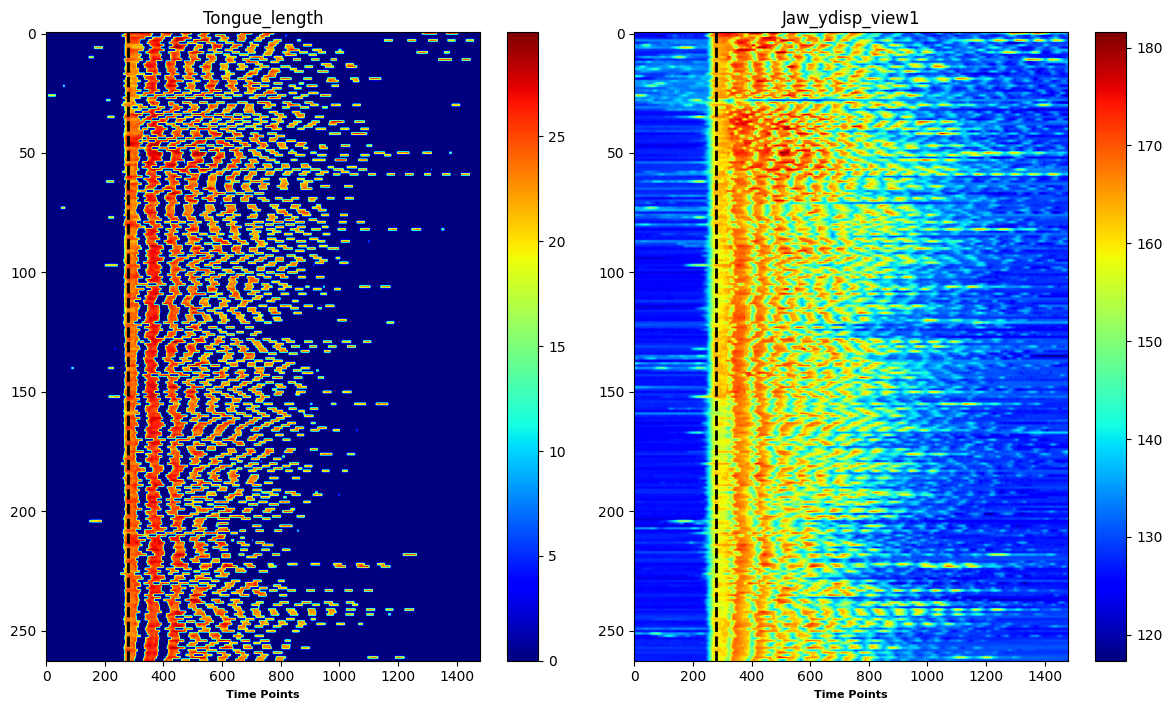

In [10]:
# Plot Heat Maps of Features 
tongue_length = np.array(feats['tongue_length'])
jaw_y = np.array(feats['jaw_ydisp_view1'])

# Reshape into (trials, time points)
tongue_length = tongue_length.reshape((tongue_length.shape[0] // trial_len, trial_len))
jaw_y = jaw_y.reshape((jaw_y.shape[0] // trial_len, trial_len))

fig, axs = plt.subplots(1, 2, figsize=(12, 8))

img1 = axs[0].imshow(tongue_length, aspect='auto', cmap='jet', origin='upper')
axs[0].set_xlabel('Time Points', fontweight='bold', fontsize=8)
axs[0].axvline(x=280, color='k', linestyle='--', linewidth=2)
axs[0].set_title('Tongue_length')
plt.colorbar(img1, ax=axs[0], orientation='vertical')  # Add color bar to first subplot

img2 = axs[1].imshow(jaw_y, aspect='auto', cmap='jet', origin='upper')
axs[1].set_xlabel('Time Points', fontweight='bold', fontsize=8)
axs[1].set_title('Jaw_ydisp_view1')
axs[1].axvline(x=280, color='k', linestyle='--', linewidth=2)
plt.colorbar(img2, ax=axs[1], orientation='vertical')  # Add color bar to first subplot

plt.tight_layout(rect=[0, 0, 1, 0.90])